In this first step, I prepared the dataset needed to compare my optimizer against the Stochastic Gradient Descent results from the original work by Julian, and ensure that both optimizers use the same initial turbine designs (from the same random seeds he used) , so the comparison is fair.

### Data Source
I downloaded the complete dataset from the project repository, which includes:

- The original code used to generate all test cases

- The simulation results

- Approximately 10.68 GB of data covering multiple wind farm configurations

The key folder used in this step, in my computer is: sgd_data/square_runs


Inside this folder, the data is organized by:

- Optimization method: det (deterministic slsqp) or sgd

- Number of rows (turbine layout density): rows_10, rows_12, rows_15, rows_18

- Random seed: seed_1 to seed_20

- Each seed folder contains files like det_x.npy and det_y.npy, which store the x and y coordinates of the turbines for that specific run.



The Python script below automates the extraction process:

In [ ]:
#!/usr/bin/env python3
import numpy as np
from pathlib import Path

base_path = Path("/Users/brunoboer/Downloads/sgd_data/square_runs") #this is in my local machine
output_mae = Path(__file__).parent / "Cases_DTU" # you can check this folder here : Optimizers_Bruno/Designs/Cases_DTU
output_mae.mkdir(exist_ok=True)

row_configs = {
    10: (100, (10-1)*5*80),
    12: (144, (12-1)*5*80),
    15: (225, (15-1)*5*80),
    18: (324, (18-1)*5*80)
}

for rows_str, (n_turb, L) in row_configs.items():
    det_dir = base_path / f"rows_{rows_str}_det"
    
    if not det_dir.exists():
        print(f"{det_dir} does not exist")
        continue
    
    pasta_rows = output_mae / f"rows_{rows_str}_T"
    pasta_rows.mkdir(exist_ok=True)
    
    x0, y0, x1, y1 = 0.0, 0.0, L, L
    print(f"\nProcessing {det_dir.name} -> {n_turb} turbines [{L:.0f}m]")
    
    seeds_ok = 0
    for seed in range(1, 21):
        seed_dir = det_dir / f"seed_{seed}"  
        
        if not (seed_dir / 'det_x.npy').exists():
            continue  
        
        sgd_x = np.load(seed_dir / 'det_x.npy')
        sgd_y = np.load(seed_dir / 'det_y.npy')
        x_init, y_init = sgd_x[0], sgd_y[0]
        
        if len(x_init) == n_turb:
            csv_name = f"{n_turb}turb_{L:.0f}m_kdt_{seed}.csv"
            csv_path = pasta_rows / csv_name
            
            with open(csv_path, 'w') as f:
                f.write("x_coordinate,y_coordinate,x0,y0,x1,y1\n")
                for xi, yi in zip(x_init, y_init):
                    f.write(f"{xi:.6f},{yi:.6f},{x0:.1f},{y0:.1f},{x1:.1f},{y1:.1f}\n")
            
            seeds_ok += 1
            print(f"  seed_{seed} -> {csv_name} saved")
    
    print(f"  Summary: {seeds_ok}/20 completed -> {pasta_rows.name}")

print(f"\nCases_DTU finished ")

Defines the mapping between row configurations and turbine counts:

```
rows_10 → 100 turbines, domain size L = 3600m

rows_12 → 144 turbines, domain size L = 4000m

rows_15 → 225 turbines, domain size L = 4800m

rows_18 → 324 turbines, domain size L = 5600m
```

Saves each valid initial design as a CSV file with the format:



x_coordinate,y_coordinate,x0,y0,x1,y1


Where x0, y0, x1, y1 define the domain boundaries.

```
Cases_DTU/
    rows_10_T/
        100turb_3600m_kdt_1.csv
        100turb_3600m_kdt_2.csv
        ...
    rows_12_T/
        144turb_4000m_kdt_1.csv
        ...
    rows_15_T/
        ...
    rows_18_T/
        ...
```

These CSV files will be used as the initial designs for both my optimizer and SGD

# Re-evaluating DTU Results with my metrics and classes 

The original work used TopFarm to compute AEP and constraints, but I couldn't replicate their code exactly with TopFarm in my setup. That's a problem: if I compare my optimizer's AEP numbers against their SGD numbers, but if we're using different ways to calculate AEP, the comparison isn't fair.

So I did this: I re-evaluated every optimization run they published, using my own components (my AEP calculator, my spacing constraint, my boundary constraint, my RMS penalty).

### What the Script Does
I loaded the same .npy files they saved (turbine positions at each iteration), and for every case I computed:

- AEP using my AEPComp (with BastankhahGaussian wake model)

- Spacing constraints using my SpacingConstraintComp (min 2D = 160m)

- Boundary constraints using my BoundaryConstraintComp (square domain)

- RMS violation using my FinalRMSViol (aggregated violation)

I did this for both the initial design (iteration 0) and the final design (last iteration), so I can compare start and end points 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from aep import AEPComp  
from constraints import SpacingConstraintComp, BoundaryConstraintComp
from aggregator import ConstraintAggregator
from penalty import FinalRMSViol

from py_wake.examples.data.lillgrund import LillgrundSite
from py_wake.examples.data.hornsrev1 import HornsrevV80
from py_wake.deficit_models.gaussian import BastankhahGaussian

site = LillgrundSite()
site.interp_method = 'linear'
wfm = BastankhahGaussian(site, HornsrevV80())

base_path = Path("/Users/brunoboer/Downloads/sgd_data/square_runs")#my local machine
output = Path(__file__).parent / "DTU_Recorders_Init_End_Full" #you can find the output files here: Optimizers_Bruno/DTU_Recorders_Init_End
output.mkdir(exist_ok=True)

row_configs = {
    10: (100, (10-1)*5*80),
    12: (144, (12-1)*5*80),
    15: (225, (15-1)*5*80),
    18: (324, (18-1)*5*80)
}

D = 80.0
min_spacing_m = 2 * D

def process_init_end(rows_str, n_wt, L, data_dir, case_type, seed, prefix='sgd'):
    data_path = data_dir / f"seed_{seed}"
    
    x_file = data_path / f'{prefix}_x.npy'
    y_file = data_path / f'{prefix}_y.npy'
    time_file = data_path / f'{prefix}_time.npy'
    
    if not all(f.exists() for f in [x_file, y_file, time_file]):
        return False
    
    x_pos = np.load(x_file)
    y_pos = np.load(y_file)
    times = np.load(time_file)
    
    T = x_pos.shape[0]
    iters = [0, T-1]  
    
    boundary_vertices = np.array([[0,0], [L,0], [L,L], [0,L]])
    
    aep_comp = AEPComp(wake_model=wfm, wt_x=np.zeros(n_wt), wt_y=np.zeros(n_wt)); aep_comp.setup()
    spacing_comp = SpacingConstraintComp(n_turbines=n_wt, min_spacing=min_spacing_m); spacing_comp.setup()
    boundary_comp = BoundaryConstraintComp(boundary_vertices=boundary_vertices, n_turbines=n_wt); boundary_comp.setup()
    agg_comp = ConstraintAggregator(n_turbines=n_wt); agg_comp.setup()
    rms_comp = FinalRMSViol(nconstraints=agg_comp.m_total); rms_comp.setup()
    
    rows = []
    time0 = times[0]
    
    for i, iter_idx in enumerate(iters):
        x_pos_i = x_pos[iter_idx]
        y_pos_i = y_pos[iter_idx]
        time_s = times[iter_idx] - time0
        
        inputs = {'x': x_pos_i, 'y': y_pos_i}; outputs = {'aep': np.zeros(1)}
        aep_comp.compute(inputs, outputs); aep = float(outputs['aep'])
        
        inputs_s = {'x': x_pos_i, 'y': y_pos_i}; outputs_s = {'spacing_cons': np.zeros(spacing_comp.m)}
        spacing_comp.compute(inputs_s, outputs_s); spacing_cons = outputs_s['spacing_cons']
        
        inputs_b = {'x': x_pos_i, 'y': y_pos_i}; outputs_b = {'boundary_cons': np.zeros(n_wt)}
        boundary_comp.compute(inputs_b, outputs_b); boundary_cons = outputs_b['boundary_cons']
        
        inputs_g = {'spacing_cons': spacing_cons, 'boundary_cons': boundary_cons}
        outputs_g = {'g_vector': np.zeros(agg_comp.m_total)}
        agg_comp.compute(inputs_g, outputs_g); g_vector = outputs_g['g_vector']
        
        inputs_r = {'g_vector': g_vector}; outputs_r = {'rms_viol': np.array(0.0)}
        rms_comp.compute(inputs_r, outputs_r); rms_viol = float(outputs_r['rms_viol'])
        
        rows.append({
            'eval': iter_idx+1, 'time_s': time_s, 'iter': iter_idx,
            'obj': -aep, 'aep': aep, 'rms_viol': rms_viol,
            'x': ';'.join(f"{xi:.3f}" for xi in x_pos_i),
            'y': ';'.join(f"{yi:.3f}" for yi in y_pos_i),
            'label': 'init' if iter_idx == 0 else 'end'
        })
    
    df = pd.DataFrame(rows)
    pasta_saida = output / case_type / f"rows_{rows_str}_T"
    pasta_saida.mkdir(parents=True, exist_ok=True)
    
    if prefix == 'sgd':
        csv_name = f'dtu_{n_wt}wt_T{T}_{prefix}_{case_type}_seed{seed}.csv'
    else:
        csv_name = f'dtu_{n_wt}wt_T{T}_{case_type}_seed{seed}.csv'
    
    df.to_csv(pasta_saida / csv_name, index=False)
    return True

print("DTU Init+End FULL")

print("\n📁 SGD 500/1000/2000...")
for rows_str, (n_wt, L) in row_configs.items():
    for T_target in [500, 1000, 2000]:
        sgd_dir = base_path / f"rows_{rows_str}_T_{T_target}"
        if sgd_dir.exists():
            print(f"  {sgd_dir.name}...")
            for seed in range(1, 21):
                process_init_end(rows_str, n_wt, L, sgd_dir, f"T{T_target}", seed, 'sgd')

print("\n📁 SLSQP det...")
for rows_str, (n_wt, L) in row_configs.items():
    det_dir = base_path / f"rows_{rows_str}_det"
    if det_dir.exists():
        print(f"  {det_dir.name}...")
        for seed in range(1, 21):
            process_init_end(rows_str, n_wt, L, det_dir, "slsqp", seed, 'det')

print(f"\n CSVs saved to {output}")

You can find the output folder here : Optimizers_Bruno/DTU_Recorders_Init_End

For each case, the csv file contains :

```
| Column   | What it is                                      |
| -------- | ----------------------------------------------- |
| eval     | Evaluation number (1 = initial, last = final)   |
| time_s   | Time elapsed in seconds                         |
| iter     | Iteration index (0 or T-1)                      |
| obj      | Objective value (-AEP)                          | 
| aep      | Annual Energy Production in MW                  |
| rms_viol | RMS constraint violation                        |
| x        | All turbine x coordinates (semicolon-separated) |
| y        | All turbine y coordinates (semicolon-separated) |
| label    | 'init' or 'end'                                 |
```

** obj is the -AEP because in my optimization, I enter this value negative. But here is just re-validation using the same components.


Output folder structure:
```
DTU_Recorders_Init_End_Full/
    T500/
        rows_10_T/
            dtu_100wt_T500_sgd_T500_seed1.csv
            dtu_100wt_T500_sgd_T500_seed2.csv
            ...
        rows_12_T/
            ...
    T1000/
        ...
    T2000/
        ...
    slsqp/
        rows_10_T/
            dtu_100wt_Tslsqp_seed1.csv
            dtu_100wt_Tslsqp_seed2.csv
            ...
```

I also generated a boxplot comparing SGD vs SLSQP results across all cases.

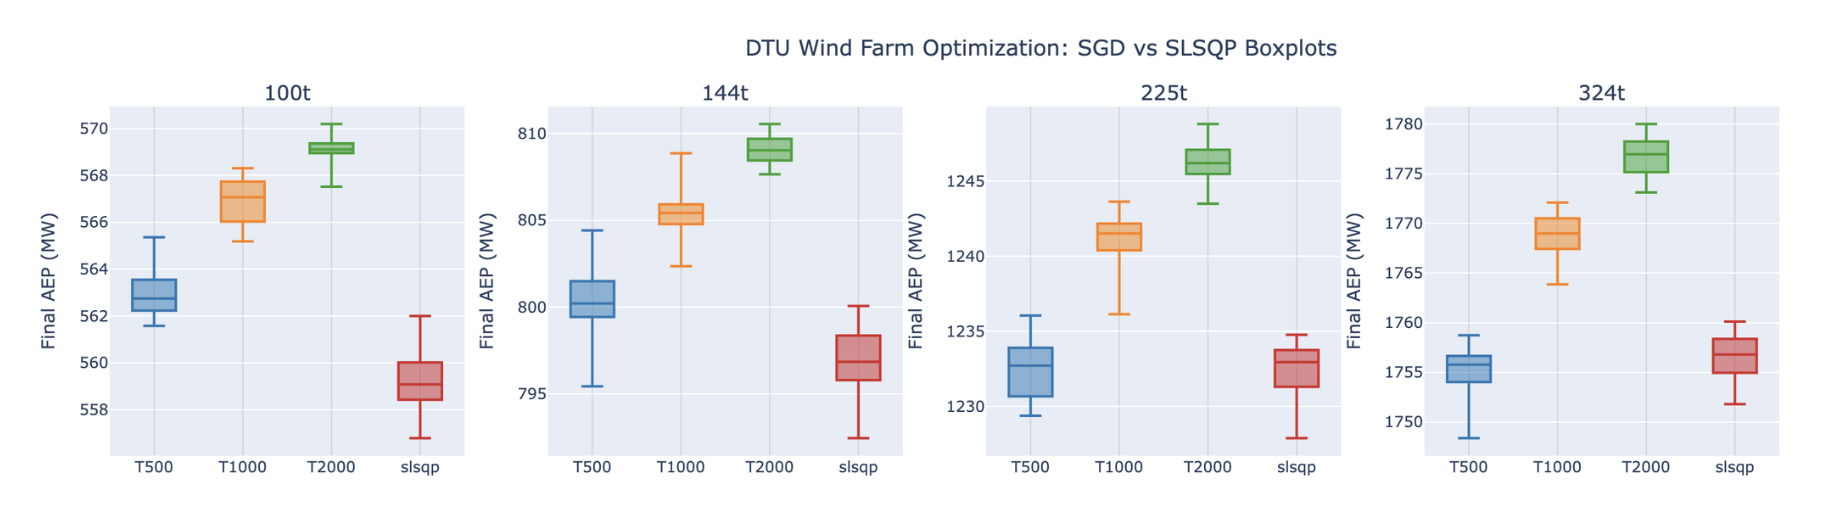